In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

$x^3 - 5x^2 + 4.5$ on [4.5, 5]

In [2]:
def f(x) -> float:
    return x ** 3 - 5 * x ** 2 + 4.5

In [3]:
def cubic_spline_interpolation(x, y):
    """
    Функция вычисляет коэффициенты кубического сплайна для набора точек.
    :param x: Массив узловых точек
    :param y: Массив значений функции в узловых точках
    :return: b, c, d - массивы коэффициентов для каждого подотрезка
    """
    n = len(x) - 1 # кол-во интервалов между точками
    h = np.diff(x) # массив длин каждого интервала
    alpha = np.zeros(n) # массив для правой части уравнений для системы прогонки
    
    # Вычисляем значения для правой части системы уравнений, используя разности в y между соседними точками
    for i in range(1, n):
        alpha[i] = ((3 / h[i]) * (y[i + 1] - y[i]) 
                    - (3 / h[i - 1]) * (y[i] - y[i - 1]))

    l = np.ones(n + 1) # массив для прогонки (вектор диагонали матрицы)
    mu = np.zeros(n) # массив для коэффициентов прогонки (верхняя диагональ)
    z = np.zeros(n + 1) # массив для правой части системы уравнений
    
    # Прямой ход метода прогонки для нахождения промежуточных коэффициентов
    for i in range(1, n):
        # диагональный элемент матрицы, на который происходит деление
        l[i] = 2 * (x[i + 1] - x[i - 1]) - h[i - 1] * mu[i - 1]
        # коэффициент для верхней диагонали
        mu[i] = h[i] / l[i]
        # решение для текущего шага прогонки
        z[i] = (alpha[i] - h[i] * z[i - 1]) / l[i]
    
    b = np.zeros(n) # коэффициенты при (x - x_i)
    c = np.zeros(n + 1) # коэффициенты при (x - x_i)^2
    d = np.zeros(n) # коэффициенты при (x - x_i)^3
    
    # Обратный ход метода прогонки для нахождения окончательных коэффициентов
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j + 1]
        b[j] = (y[j + 1] - y[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])
    return b, c, d

In [4]:
def evaluate_spline(x, x_data, y_data, b, c, d):
    """
    Функция вычисляет значение сплайна в заданной точке x.
    :param x: Точка, в которой нужно вычислить значение сплайна
    :param x_data: Массив узловых точек
    :param y_data: Массив значений функции в узловых точках
    :params b, c, d: Массивы коэффициентов для каждого подотрезка 
    :return: Значение сплайна в точке x.
    """
    # По всем интервалам ищем где находится x.
    for i in range(len(x_data) - 1):
        if x_data[i] <= x <= x_data[i + 1]:
            h = x - x_data[i] # расстояние от x до ближайшей левой точки
            # значение сплайна по формуле кубического полинома
            return y_data[i] + b[i] * h + c[i] * h ** 2 + d[i] * h ** 3
    # x не в интервале
    return None

In [11]:
x = np.linspace(4.5, 5, 5)
y = f(x)
display(x, y)

array([4.5  , 4.625, 4.75 , 4.875, 5.   ])

array([-5.625     , -3.52148438, -1.140625  ,  1.52929688,  4.5       ])

In [6]:
spline = CubicSpline(x, y)
b, c, d = cubic_spline_interpolation(x, y)

numpy.ndarray

In [7]:
x_dense = np.linspace(4.5, 5, 1000)
y_dense = f(x_dense)
y_interp = spline(x_dense)
y_spline = [evaluate_spline(a, x, y, b, c, d) for a in x_dense]

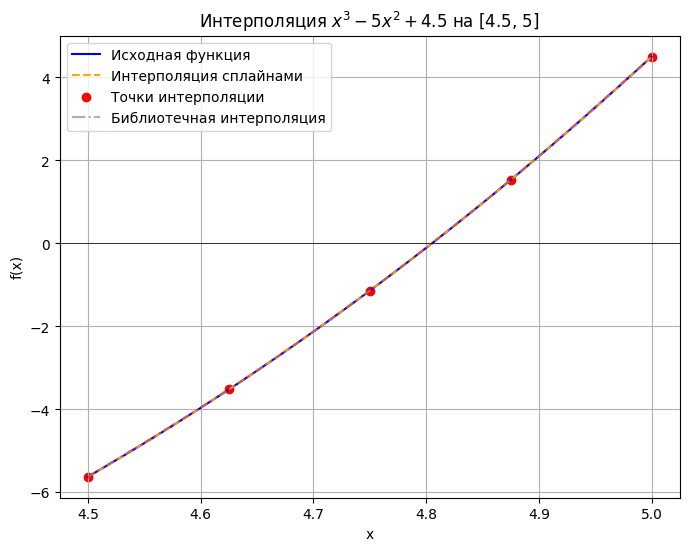

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(x_dense, y_dense, label="Исходная функция", color='blue')
plt.plot(x_dense, y_interp, '--', label="Интерполяция сплайнами", color='orange')
plt.scatter(x, y, color='red', label="Точки интерполяции")
plt.plot(x_dense, y_spline, '-.', label="Библиотечная интерполяция", color='purple', alpha=0.4)
plt.title(r'Интерполяция $x^3 - 5x^2 + 4.5$ на [4.5, 5]')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()